# 4장 복습과제 — 4-1 분류의 개요 & 4-2 결정 트리 (정답)

## **문제 1. (개념) 지도학습과 분류**

- 지도학습(Supervised Learning)이 무엇인지 한 문장으로 설명하세요.
- 분류(Classification)를 구현할 수 있는 알고리즘을 3가지 이상 적어보세요.

**답변**

- 지도학습: 레이블(Label), 즉 명시적인 정답이 있는 데이터가 주어진 상태에서 학습하는 머신러닝 방식이다.
- 분류 알고리즘 3가지: 나이브 베이즈(Naive Bayes), 로지스틱 회귀(Logistic Regression), 결정 트리(Decision Tree) (그 외 SVM, 최소 근접, 신경망, 앙상블도 가능)

## **문제 2. (개념) 정보 이득 vs 지니 계수**

결정 트리가 노드를 분할할 때 사용하는 두 가지 균일도 측정 방법인 **정보 이득(Information Gain)**과 **지니 계수(Gini Index)**를 각각 한 문장으로 설명하고, 사이킷런의 `DecisionTreeClassifier`가 기본으로 사용하는 것은 무엇인지 적으세요.

**답변**

- 정보 이득: 엔트로피(데이터 집합의 혼잡도)를 기반으로 한 지수로, 1에서 엔트로피 지수를 뺀 값이며 값이 클수록 균일도가 높다.
- 지니 계수: 경제학의 불평등 지수 개념을 가져온 것으로, 0(평등=균일)에 가까울수록 균일도가 높다고 해석한다.
- 사이킷런 기본값: 지니 계수(gini)

## **문제 3. Breast Cancer 데이터 로딩 및 train/test 분리**

- sklearn 패키지의 `load_breast_cancer` 데이터셋을 이용합니다.
- 유방암 세포의 특징(반지름, 텍스처 등)을 기반으로 악성(malignant)/양성(benign)을 분류하는 이진 분류 데이터셋입니다.
- `train_test_split`을 통해 학습용 75%, 테스트용 25%로 분리하세요. (`random_state=42`)

In [1]:
## 데이터 준비
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 데이터 로드
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# 데이터 훈련/테스트 세트로 분할 (75:25 비율, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## **문제 4. DecisionTreeClassifier로 모델 학습 및 정확도 평가**

- `criterion='gini'`, `max_depth=4`, `random_state=42`로 결정 트리 모델을 생성하고 학습시키세요.
- 테스트 데이터에 대한 예측을 수행하고 정확도(accuracy)를 출력하세요.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 모델 생성 및 학습
dt_clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_clf.fit(
    X_train, y_train
    )

# 테스트 세트에 대한 예측 및 정확도 계산
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('결정 트리 예측 정확도 : {0:.4f}'.format(accuracy))
# 실행 결과: 결정 트리 예측 정확도 : 0.9510

결정 트리 예측 정확도 : 0.9510


♦️ 노드 정보 설명

- feature <= threshold : 데이터를 나누는 기준
- gini : 노드의 불순도 (0에 가까울수록 순수)
- samples : 해당 노드에 포함된 데이터 수
- value : 각 클래스별 데이터 개수
    예: [40, 5] → 첫 번째 클래스가 대부분

## **문제 5. GridSearchCV를 이용한 하이퍼파라미터 튜닝**

- `max_depth`: [3, 5, 7, 9], `min_samples_split`: [2, 4, 6] 조합으로 그리드서치를 수행하세요.
- `cv=5`로 교차검증하고, 최적 파라미터와 최고 평균 정확도를 출력하세요.
- 최적 모델(`best_estimator_`)로 테스트 데이터 정확도를 다시 평가하세요.

In [3]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 4, 6]
}

dt = DecisionTreeClassifier(random_state=42)

grid_cv = GridSearchCV(dt, param_grid=params, scoring='accuracy', cv=5)
grid_cv.fit(X_train, y_train)

print("최적 하이퍼 파라미터:", grid_cv.best_params_)
print("최고 평균 정확도:", grid_cv.best_score_)
# 실행 결과: {'max_depth': 7, 'min_samples_split': 2} / 0.9366

# 최적 모델로 테스트 세트 재평가
best_dt_clf = grid_cv.best_estimator_
pred = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('최종 테스트 정확도 : {0:.4f}'.format(accuracy))
# 실행 결과: 최종 테스트 정확도 : 0.9510

최적 하이퍼 파라미터: {'max_depth': 7, 'min_samples_split': 2}
최고 평균 정확도: 0.9365800273597811
최종 테스트 정확도 : 0.9510


## **문제 6. Feature Importance 시각화**

- 문제 5에서 얻은 최적 모델(`best_dt_clf`)에서 `feature_importances_` 속성을 추출하세요.
- 중요도 상위 10개 피처를 막대그래프(`sns.barplot`)로 시각화하세요.

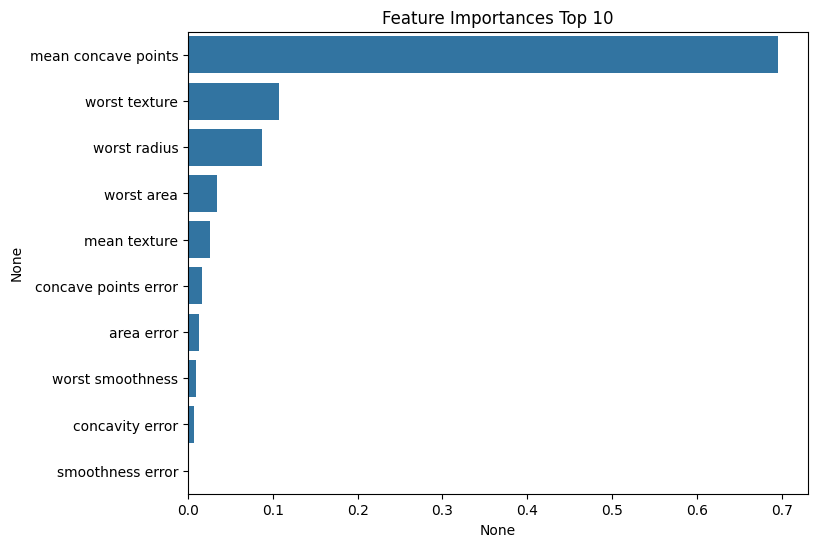

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 최적 모델에서 피처 중요도 추출
ftr_importances_values = best_dt_clf.feature_importances_

# Series로 변환
ftr_importances = pd.Series(
    ftr_importances_values,
    index=cancer.feature_names
    )

# 중요도 상위 10개만 추출
ftr_top10 = ftr_importances.sort_values(ascending=False)[:10]

# 시각화
plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 10')

sns.barplot(
    x=ftr_top10,
    y=ftr_top10.index
    )

plt.show()
# 1위 피처: mean concave points (중요도 약 0.70)로 압도적 1위

# **4-3 앙상블 학습**

# 1) 데이터셋 불러오기 및 분리
### load_breast_cancer()를 이용하여 유방암 데이터셋을 불러온 후 훈련 세트와 테스트 세트로 분리해 주세요.

* test_size = 0.25
* random_state = 113



In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,test_size=0.25, random_state=113)

# 2) 개별 분류기 학습 및 평가
### 다음 세 개의 분류기를 생성하고 각각 학습/예측한 후 정확도를 출력해 주세요.

*  Logistic Regression: solver = 'liblinear'
*  KNN: n_neighbors = 6
*  Decision Tree: max_depth=4

> #### 반복되는 학습/예측/평가 과정은 반복문을 이용하세요.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

lr_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=6)
dt_clf = DecisionTreeClassifier(max_depth=4)

classifiers = [lr_clf, knn_clf, dt_clf]

for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)

    class_name = classifier.__class__.__name__

    print('{0} 정확도: {1:.4f}'.format(class_name,accuracy_score(y_test, pred)))

LogisticRegression 정확도: 0.9371
KNeighborsClassifier 정확도: 0.9301
DecisionTreeClassifier 정확도: 0.8951


# 3) Hard Voting과 Soft Voting
### 3-1) 2번에서 생성한 세 개의 분류기를 이용하여 Hard Voting 방식의 VotingClassifier를 생성하세요.



In [7]:
from sklearn.ensemble import VotingClassifier

hard_clf = VotingClassifier(estimators=[('LR', lr_clf), ('KNN', knn_clf), ('DT', dt_clf)],
                            voting='hard')


### 3-2) 모델을 학습한 후 테스트 데이터의 정확도(소숫점 넷째자리까지)를 출력하세요.

In [8]:
hard_clf.fit(X_train, y_train)
hard_pred = hard_clf.predict(X_test)
hard_accuracy = accuracy_score(y_test, hard_pred)

print('Hard Voting 정확도: {0:.4f}'.format(hard_accuracy))

Hard Voting 정확도: 0.9441


### 3-3) Hard Voting과 Soft Voting의 차이를 설명하세요.

Hard Voting은 각 분류기가 예측한 클래스 레이블을 바탕으로 다수결을 수행한다. 반면 Soft Voting은 각 분류기의 클래스별 예측 확률을 평균하고, 평균 확률이 가장 높은 클래스를 최종 예측값으로 결정한다.

# 4) Bagging과 Pasting

### 4-1)  300개의 결정 트리가 중복을 허용하여 80개의 훈련 샘플을 추출하도록 모델을 생성하세요.
> n_jobs = -1로 설정



In [9]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=300,
                            max_samples=80, bootstrap=True, n_jobs=-1)

### 4-2)  300개의 결정 트리가 중복을 허용하지 않고 80개의 훈련 샘플을 추출하도록 모델을 생성하세요.
> n_jobs = -1로 설정

In [10]:
paste_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=300,
                            max_samples=80, bootstrap=False, n_jobs=-1)

### 4-3) 두 모델을 각각 학습하고, 예측 성능을 소숫점 넷째자리까지 평가하세요. (이때, 각 모델의 학습방식을 함께 표시하여 출력하세요.)
        출력 방식: Bagging/Pasting 정확도: 0.xxxx



In [11]:
bag_clf.fit(X_train, y_train)
bag_pred = bag_clf.predict(X_test)
bag_accuracy = accuracy_score(y_test, bag_pred)

paste_clf.fit(X_train, y_train)
paste_pred = paste_clf.predict(X_test)
paste_accuracy = accuracy_score(y_test, paste_pred)

print('Bagging 정확도: {0:.4f}'.format(bag_accuracy))
print('Pasting 정확도: {0:.4f}'.format(paste_accuracy))

Bagging 정확도: 0.9301
Pasting 정확도: 0.9091


# 5) oob 평가
### 5-1) 4번의 Bagging 모델과 동일한 조건으로 oob 평가가 가능한 모델을 생성하고 학습하세요.

In [12]:
oob_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300, max_samples=80,
                           bootstrap=True, n_jobs=-1, oob_score=True)

oob_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=80,
                  n_estimators=300, n_jobs=-1, oob_score=True)

### 5-2) 학습된 모델의 oob 점수와 테스트 데이터셋에 대한 정확도를 각각 소수점 넷째 자리까지 출력하여 비교하세요.

In [13]:
print('oob Score: {0:.4f}'.format(oob_clf.oob_score_))

oob_pred = oob_clf.predict(X_test)
print('Test Set Accuracy: {0:.4f}'.format(accuracy_score(y_test, oob_pred)))

oob Score: 0.9507
Test Set Accuracy: 0.9371


oob Score와 Test Set Accuracy가 유사한 값을 보임을 확인할 수 있다.

# 랜덤 포레스트
1) 사이킷런의 load_digits 데이터셋을 RandomForestClassifier을 이용해 예측하시오.

## 답안

In [14]:
# 필요한 라이브러리 임포트 - 실행해주세요!
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


# 데이터셋 설정
digits = load_digits()
digits_data = digits.data
digits_target = digits.target


# 데이터를 학습/테스트 데이터로 분리
# test_size = 0.25, random_state = 21
X_train, X_test, y_train, y_test = train_test_split(
    digits_data,
    digits_target,
    test_size=0.25,
    random_state=21
)


# Random Forest 객체 생성 및 예측
digits_rf = RandomForestClassifier(random_state=10, max_depth=7)
digits_rf.fit(X_train, y_train)
pred = digits_rf.predict(X_test)


# estimate accuracy
acc = accuracy_score(y_test, pred)
print('Random Forest accuracy: {0:.4f}'.format(acc))


Random Forest accuracy: 0.9600


## 정답 해설

 ### 1\. 데이터셋 불러오기

```
digits = load_digits()
```

 `load_digits()`는 사이킷런에서 제공하는 **손글씨 숫자 데이터셋**을 불러오는 함수이다.

 이 데이터셋에는 숫자 **0부터 9까지의 손글씨 이미지**가 들어 있다.

 - `digits.data` → 숫자 이미지를 학습할 수 있도록 숫자 형태로 저장한 데이터
- `digits.target` → 각 이미지가 실제로 어떤 숫자인지 나타내는 정답

 따라서 다음과 같이 저장한다.

```
digits_data = digits.data
digits_target = digits.target
```

 즉,

```
digits_data   → 문제(X), 입력 데이터
digits_target → 정답(y), 예측해야 할 숫자
```

 라고 생각하면 된다.

---

 ### 2\. 학습 데이터와 테스트 데이터로 나누기

```
X_train, X_test, y_train, y_test = train_test_split(
    digits_data,
    digits_target,
    test_size=0.25,
    random_state=21
)
```

 머신러닝에서는 가지고 있는 전체 데이터를 **학습용 데이터와 테스트용 데이터**로 나눈다.

 이번 문제에서는

```
test_size=0.25
```

 이므로 전체 데이터의 **25%는 테스트 데이터**, 나머지 **75%는 학습 데이터**가 된다.

 각 변수의 의미는 다음과 같다.

 | 변수 | 의미 |
| --- | --- |
| `X_train` | 모델을 학습시키는 입력 데이터 |
| `X_test` | 학습한 모델을 테스트하는 입력 데이터 |
| `y_train` | 학습 데이터의 실제 정답 |
| `y_test` | 테스트 데이터의 실제 정답 |

`random_state=21`은 데이터를 나눌 때 사용하는 난수의 기준값이다. 같은 값을 사용하면 **항상 같은 방식으로 데이터를 나눌 수 있다.**

---

 ### 3\. Random Forest 모델 생성

```
digits_rf = RandomForestClassifier(random_state=10, max_depth=7)
```

 `RandomForestClassifier`는 여러 개의 \*\*Decision Tree(의사결정나무)\*\*를 만들어 분류하는 머신러닝 알고리즘이다.

 여기에서는 두 가지 옵션을 설정했다.

```
random_state=10
```

 → 모델을 만들 때 사용되는 난수의 기준값이다.

```
max_depth=7
```

 → 각각의 의사결정나무가 가질 수 있는 최대 깊이를 7로 제한한다.

---

 ### 4\. 모델 학습

```
digits_rf.fit(X_train, y_train)
```

 `fit()`은 **머신러닝 모델을 학습시키는 함수**이다.

 따라서

```
digits_rf.fit(X_train, y_train)
```

 은

 > "X\_train 데이터를 사용하고, 그 데이터의 정답은 y\_train이야. 이 데이터를 이용해서 숫자를 분류하는 방법을 학습해."

 라는 의미이다.

---

 ### 5\. 테스트 데이터 예측

```
pred = digits_rf.predict(X_test)
```

 `predict()`는 학습된 모델을 이용해서 새로운 데이터의 결과를 예측하는 함수이다.

 여기서는 학습에 사용하지 않았던 `X_test`를 넣어서 숫자를 예측한다.

 예를 들어 실제 숫자가 다음과 같다고 하면,

```
실제 정답:  [3, 7, 1, 9, 5]
```

 Random Forest가 다음과 같이 예측할 수 있다.

```
예측 결과:  [3, 7, 1, 8, 5]
```

 이 예측 결과를 `pred`에 저장한다.

---

 ### 6\. 정확도 계산

```
acc = accuracy_score(y_test, pred)
```

 `accuracy_score()`는 **실제 정답과 모델의 예측이 얼마나 일치하는지** 계산한다.

```
accuracy_score(실제 정답, 예측값)
```

 형태로 사용한다.

 따라서

```
accuracy_score(y_test, pred)
```

 는

 > `y_test`의 실제 정답과 `pred`의 예측 결과를 비교해서 정확도를 계산한다.

 는 의미이다.

 예를 들어 100개의 테스트 데이터 중 95개를 정확하게 예측했다면 정확도는

```
95 / 100 = 0.95
```

 가 된다.

---

 ### 7\. 정확도 출력

```
print('Random Forest accuracy: {0:.4f}'.format(acc))
```

 `{0:.4f}`에서 `.4f`는 **소수점 아래 4자리까지 표시**하라는 의미이다.

 예를 들어 정확도가 `0.956123`이라면

```
Random Forest accuracy: 0.9561
```

 처럼 출력된다.


2) load_wine 데이터셋을 이용하여 GradientBoostingClassifier 모델을 학습하고, GridSearchCV를 활용하여 최적의 하이퍼파라미터를 찾으시오.

## 답안

In [15]:
# 필요한 라이브러리 임포트
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


# 데이터셋 로드
wine = load_wine()
wine_data = wine.data
wine_target = wine.target


# 훈련 세트와 테스트 세트로 분리
# test_size=0.25, random_state=21
X_train, X_test, y_train, y_test = train_test_split(
    wine_data,
    wine_target,
    test_size=0.25,
    random_state=21
)


# 하이퍼파라미터 그리드 설정
params = {
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 4, 6]
}


# GradientBoostingClassifier 객체 생성 후 GridSearchCV 수행
gb_clf = GradientBoostingClassifier(random_state=21)
grid_cv = GridSearchCV(
    gb_clf,
    param_grid=params,
    cv=4,
    n_jobs=-1
)


# 모델 학습
grid_cv.fit(X_train, y_train)


# 최적 하이퍼파라미터 출력
print('최적 하이퍼파라미터:\n', grid_cv.best_params_)


# 최적 모델로 테스트 데이터 예측
y_pred = grid_cv.predict(X_test)


# 정확도 출력
accuracy = accuracy_score(y_test, y_pred)
print('Gradient Boosting 예측 정확도: {0:.4f}'.format(accuracy))


최적 하이퍼파라미터:
 {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Gradient Boosting 예측 정확도: 0.9333


# 서포트 벡터 머신(SVM)
3) 가우시안 RBF 커널을 사용하여 gamma 값이 2이고, 하이퍼파라미터 C의 값이 0.001인 SVM 분류기를 만드시오.

 - '##답변 작성## 부분에 코드를 작성해주세요.
 - '##답변 작성##' 이 아닌 부분(변수명, 미리 작성된 코드)은 수정하지 마세요.
## 답안

In [16]:
# 필요한 라이브러리 임포트
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# moons 형태의 데이터 생성
X, y = make_moons(n_samples=200, noise=0.25)

# Pipeline 생성
rbf_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='rbf', gamma=2, C=0.001))
])

# 모델학습
rbf_kernel_svm_clf.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=0.001, gamma=2))])

 ## 정답 해설

 ### 1\. Pipeline 구성

 SVM 모델을 학습하기 전에 데이터를 표준화하고, 그 결과를 SVM에 전달하도록 Pipeline을 구성한다.

```
rbf_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='rbf', gamma=2, C=0.001))
])
```

 Pipeline은 여러 작업을 **순서대로 연결하여 한 번에 처리**할 수 있도록 해준다.

 이번 문제에서는 다음 순서로 진행된다.

```
입력 데이터 X
    ↓
StandardScaler()
    ↓
SVC()
    ↓
예측
```

---

 ### 2\. 데이터 표준화

```
('scaler', StandardScaler())
```

 `StandardScaler()`는 각 특성의 값들을 일정한 기준으로 변환해준다.

 SVM은 데이터의 크기나 스케일에 영향을 받을 수 있기 때문에, SVM을 학습하기 전에 데이터를 표준화하는 것이 일반적이다.

 따라서 Pipeline의 첫 번째 단계에 `StandardScaler()`를 넣는다.

---

 ### 3\. RBF 커널 SVM 설정

```
('svm_clf', SVC(kernel='rbf', gamma=2, C=0.001))
```

 `SVC()`를 사용하여 SVM 분류 모델을 만든다.

 문제에서 **가우시안 RBF 커널**을 사용하라고 했으므로

```
kernel='rbf'
```

 로 설정한다.

 또한 문제에서 지정한 하이퍼파라미터는 다음과 같다.

```
gamma=2
C=0.001
```

 각 값의 역할은 간단히 다음과 같다.

 - `kernel='rbf'` → RBF 커널을 사용한다.
- `gamma=2` → RBF 커널에서 각 데이터가 주변 데이터에 미치는 영향의 범위를 결정한다.
- `C=0.001` → 분류 오류를 얼마나 허용할지와 관련된 하이퍼파라미터이다.

 따라서 최종적인 SVM 모델은 다음과 같다.

```
SVC(kernel='rbf', gamma=2, C=0.001)
```

---

 ### 4\. 모델 학습

```
rbf_kernel_svm_clf.fit(X, y)
```

 앞에서 만든 Pipeline에 데이터 `X`와 정답 `y`를 넣어 모델을 학습한다.

 Pipeline을 사용했기 때문에 `fit()`을 실행하면 자동으로 다음 과정이 진행된다.

```
X
 ↓
StandardScaler로 표준화
 ↓
RBF 커널 SVM으로 학습
```

 따라서 `StandardScaler()`와 `SVC()`를 각각 따로 실행할 필요가 없다.
